In [680]:
# All imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder

* Dataset source Kaggle
* Read the data and our targer variable is price

In [681]:
# Read the data
df = pd.read_csv('../Data/Zillow_top20_states.csv')
df.head()

,zpid,state_code,state_name,address,street,city,zipcode,price,price_formatted,beds,...,latitude,longitude,status,home_type,days_on_zillow,zestimate,detail_url,has_open_house,open_house_date,is_featured
0,17264897,CA,California,"979 Kevin Ave, Redlands, CA 92373",979 Kevin Ave,Redlands,92373,447000,"$447,000",3.0,...,34.040520,-117.186195,House for sale,SINGLE_FAMILY,5,455500.0,https://www.zillow.com/homedetails/979-Kevin-A...,False,NaN,False
1,20021372,CA,California,"13114 Addison St, Sherman Oaks, CA 91423",13114 Addison St,Sherman Oaks,91423,2795000,"$2,795,000",4.0,...,34.160885,-118.418770,House for sale,SINGLE_FAMILY,8,NaN,https://www.zillow.com/homedetails/13114-Addis...,True,2026-02-08T12:00:00,False
2,20009320,CA,California,"6032 Goodland Ave, North Hollywood, CA 91606",6032 Goodland Ave,North Hollywood,91606,1718000,"$1,718,000",4.0,...,34.180450,-118.411280,House for sale,SINGLE_FAMILY,8,1695500.0,https://www.zillow.com/homedetails/6032-Goodla...,False,NaN,False
3,460204882,CA,California,"3325 Tonopah St, Oceanside, CA 92054",3325 Tonopah St,Oceanside,92054,899999,"$899,999",3.0,...,33.214260,-117.341500,Coming soon,SINGLE_FAMILY,4,NaN,https://www.zillow.com/homedetails/3325-Tonopa...,False,NaN,False
4,20769150,CA,California,"963 Pine Grove Ave, Los Angeles, CA 90042",963 Pine Grove Ave,Los Angeles,90042,995000,"$995,000",2.0,...,34.132890,-118.186220,House for sale,SINGLE_FAMILY,5,999900.0,https://www.zillow.com/homedetails/963-Pine-Gr...,False,NaN,False


* Understand the structure of the data
* Data cleaning, handleing the missing values

In [682]:
df.info()
df.describe()
print(df.columns)
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 2214 entries, 0 to 2213
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   zpid             2214 non-null   int64  
 1   state_code       2214 non-null   str    
 2   state_name       2214 non-null   str    
 3   address          2214 non-null   str    
 4   street           2214 non-null   str    
 5   city             2214 non-null   str    
 6   zipcode          2214 non-null   int64  
 7   price            2214 non-null   int64  
 8   price_formatted  2214 non-null   str    
 9   beds             2205 non-null   float64
 10  baths            2206 non-null   float64
 11  area_sqft        2154 non-null   float64
 12  latitude         2210 non-null   float64
 13  longitude        2210 non-null   float64
 14  status           2214 non-null   str    
 15  home_type        2214 non-null   str    
 16  days_on_zillow   2214 non-null   int64  
 17  zestimate        1102 non

open_house_date    1784
zestimate          1112
area_sqft            60
beds                  9
baths                 8
latitude              4
longitude             4
street                0
city                  0
state_name            0
state_code            0
zpid                  0
address               0
price_formatted       0
price                 0
zipcode               0
home_type             0
status                0
days_on_zillow        0
detail_url            0
has_open_house        0
is_featured           0
dtype: int64

* We removed listing with missing target prices
* and fill the missing values using the median

In [683]:
# Drop rows with target variable
df = df.dropna(subset=["price"])

# Fill numeric missing values
df = df.fillna(df.median(numeric_only=True))

# Drop column
colsToDrop = ["zipcode", "address", "street", "price_formatted", "detail_url", ]
df.drop(columns=colsToDrop, errors="ignore", inplace=True)

df.shape

(2214, 17)

* Save the cleaned data
* Read the cleaned data for further use

In [684]:
df.to_csv('../Data/cleaned.csv', index=False)
df = pd.read_csv('../Data/cleaned.csv')

* Price distribution

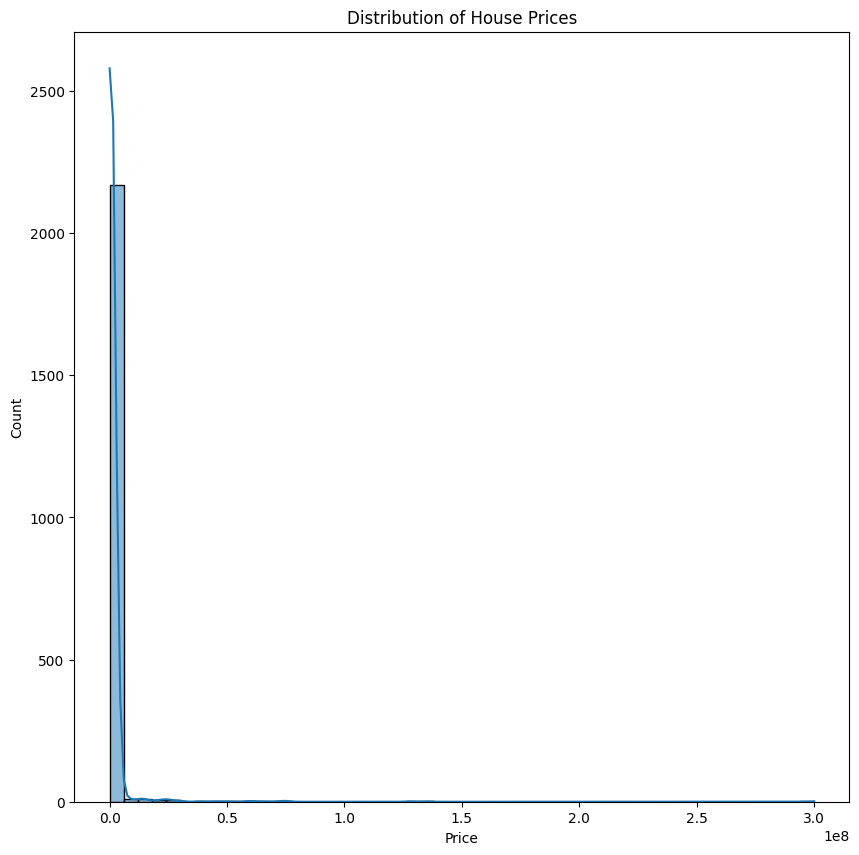

In [685]:
# Price distribution
plt.figure(figsize=(10,10))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

Most houses in the dataset are less expenisve or mid-priced, and only a few are very expensive. This uneven shape our model might work better if we handle those unusually high prices or use special transformation to make the data more balanced.

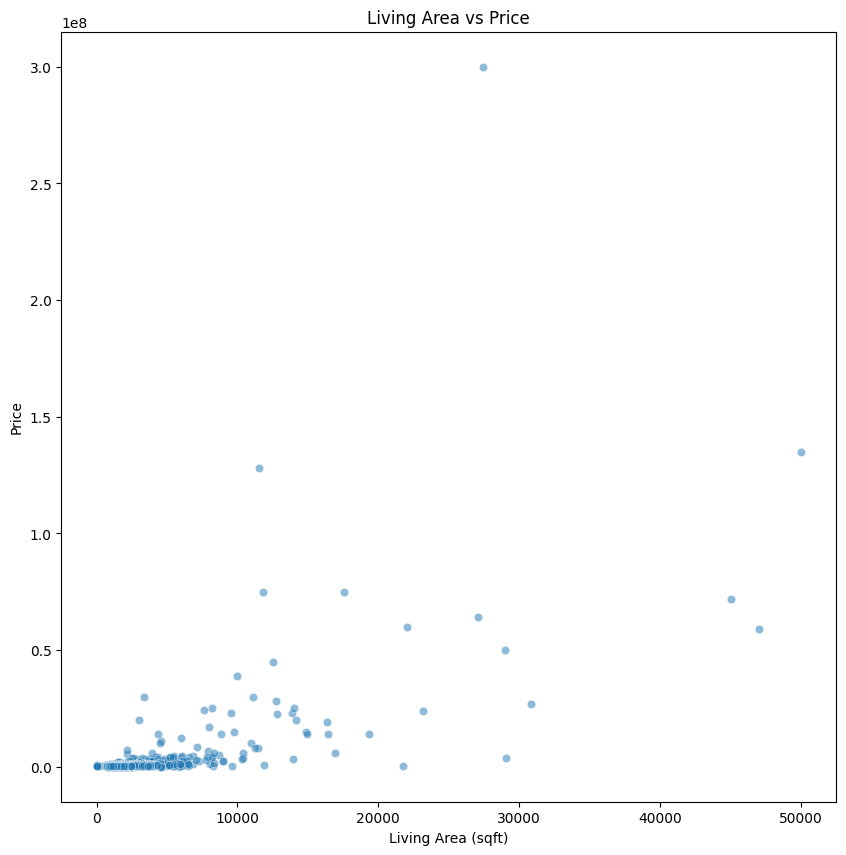

In [686]:
# Living area vs price
plt.figure(figsize=(10,10))
sns.scatterplot(x="area_sqft", y="price", data=df, alpha=0.5)
plt.title("Living Area vs Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.show()

This is a postitive relationship between living area and house price, with larger homes generally more expensives. The relationship is not strictly linear, indicating that additional factors such as location and home type also play improtant role in price

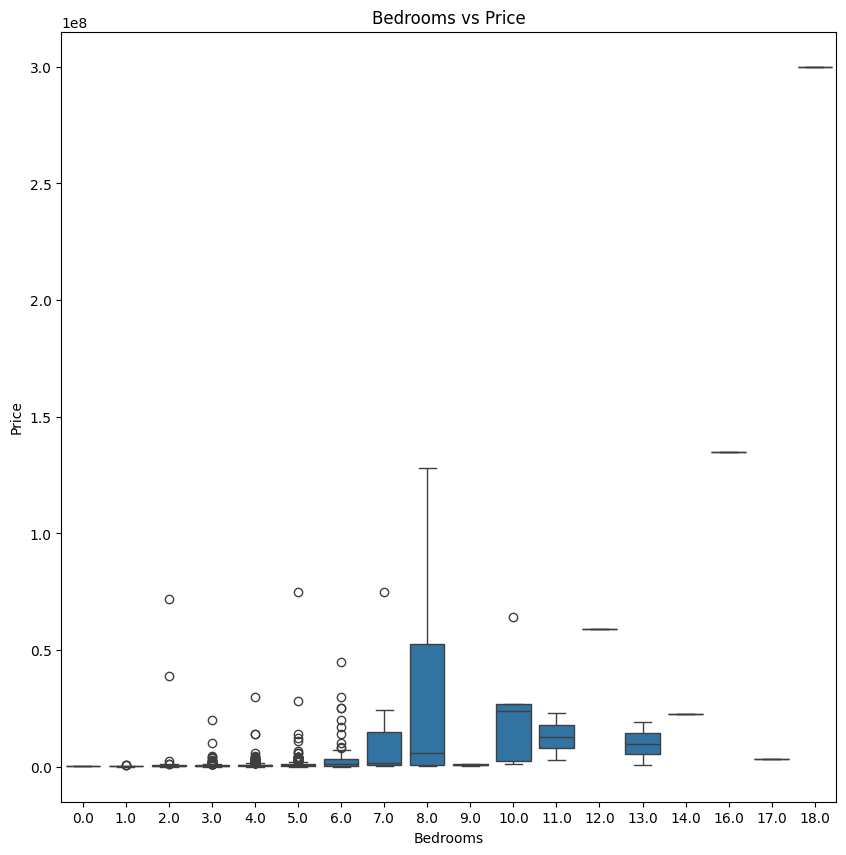

In [687]:
# Bedrooms vs price
plt.figure(figsize=(10,10))
sns.boxplot(x="beds", y="price", data=df)
plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

House price generally increase with the number of bedrooms, it also show how price are pread out. This means that after a certian number of bedrooms even after adding more doesnot increase the price.

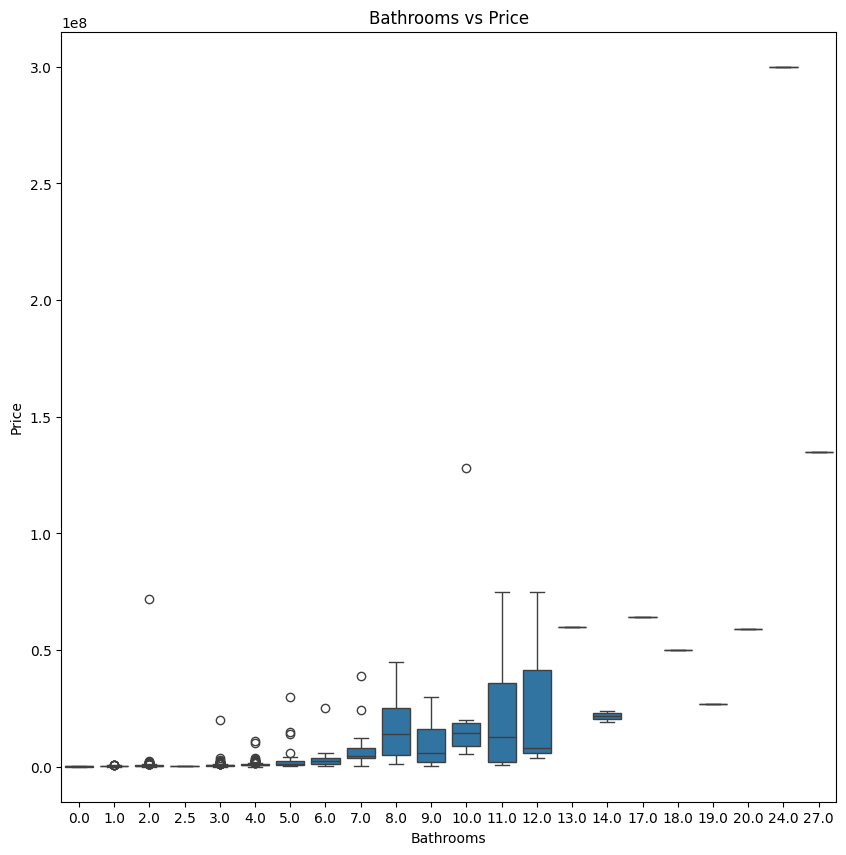

In [688]:
# Bathrooms vs price
plt.figure(figsize=(10,10))
sns.boxplot(x="baths", y="price", data=df)
plt.title("Bathrooms vs Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.show()

The number of bathrooms shows a stronger and more consistent relationship with price compared to bedrooms, means bathroom also increase the house price

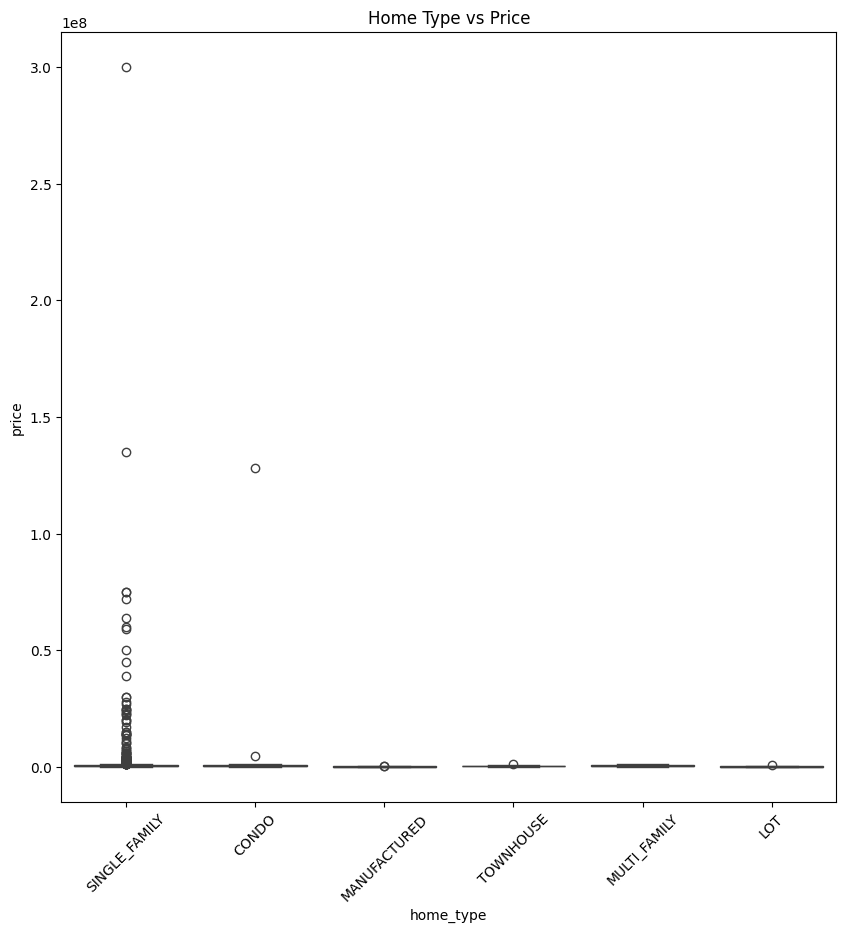

In [689]:
# Home type vs price
plt.figure(figsize=(10,10))
sns.boxplot(x="home_type", y="price", data=df)
plt.xticks(rotation=45)
plt.title("Home Type vs Price")
plt.show()

Single family homes cost more then condos and townhouses. This shows how home type as a categorical feature during modeling.

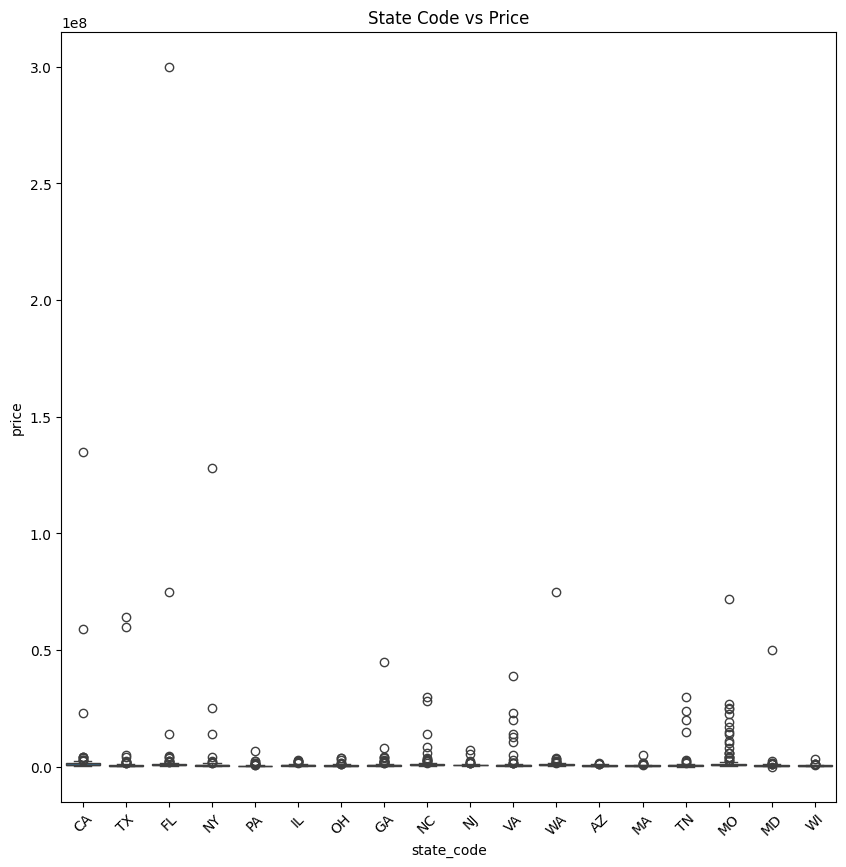

In [690]:
# state vs price
plt.figure(figsize=(10,10))
sns.boxplot(x="state_code", y="price", data=df)
plt.xticks(rotation=45)
plt.title("State Code vs Price")
plt.show()

Housing prices are different across states, confirming that geographic location pays a good role in house price

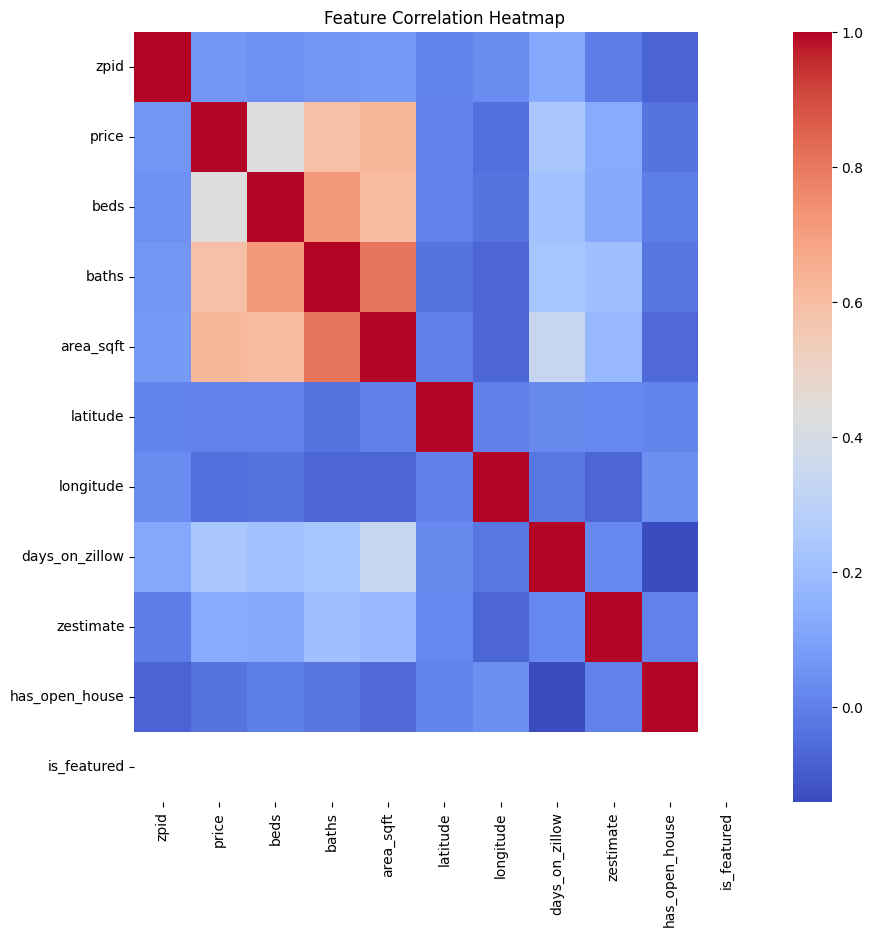

In [691]:
# Correlation heatmap
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

Size of the home, number of bathrooms, and number of bedrooms all have a positive correlations with price. Other variables such as days on market and latitude, or location show weaker relationships.

# Observation
The price graph is uneven, as most of the houese are less expensive and very few are most expensive ones pulling the curve to the right. Bigger homes with more bathrooms cost more but after a certain number addming more rooms didnot increase the price as much, also location play really good role to increase or decrease the house price.
This analysis shows that houses price are highly variable. Living area, bathrooms, bedrooms, home type, and location are all important factors influencing price. These findings guided the selection of features for machine learning models in the next stage of the project.

In [692]:
# Train and test split
X = df.drop(columns=["price"])
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((1771, 16), (443, 16))

The dataset was split into 80 training and 20 tesing sets to evalute model performance on unseen data.

In [693]:
# Predict using mean of training price
mean_price = y_train.mean()
y_pred_mean = np.full(shape=len(y_test), fill_value=mean_price)

mae_mean = mean_absolute_error(y_test, y_pred_mean)
mse_mean = mean_squared_error(y_test, y_pred_mean)
r2_mean = r2_score(y_test, y_pred_mean)

mae_mean, mse_mean, r2_mean

(1565788.9099028364, 63591937013662.77, -1.4559892440590971e-06)

This baseline predicts the same average house price for all properties. It does not use any features and servers as a minimum performance benchmark.

In [694]:
# Use a single feature
X_train_area = X_train[["area_sqft"]]
X_test_area = X_test[["area_sqft"]]

lin_simple = LinearRegression()
lin_simple.fit(X_train_area, y_train)

y_pred_simple = lin_simple.predict(X_test_area)

mae_simple = mean_absolute_error(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

mae_simple, mse_simple, r2_simple

(1867118.9336945068, 44194016966927.49, 0.3050364025954151)

This baseline uses only living area to predict house price. It captures basic trends while remaining really simple.

In [695]:
# Compare
baseline_result = pd.DataFrame({
    "Model": ["Mean Predict", "Simple Linear Regression"],
    "MAE": [mae_mean, mae_simple],
    "MSE": [mse_mean, mse_simple],
    "R2": [r2_mean, r2_simple],
})
baseline_result

,Model,MAE,MSE,R2
0,Mean Predict,1.565789e+06,6.359194e+13,-0.000001
1,Simple Linear Regression,1.867119e+06,4.419402e+13,0.305036


This simple linear refression baseline performs better than the mean predictor across all metrics. This indicates that living area can provides variable predictive information, but more complex models are expected to further improve performance.

Baseline models allows us to evaluate whether more complex machine learning models truly add value. 

In [696]:
# Separate features by type
numeric_features = [
    "beds",
    "baths",
    "area_sqft",
]

categorical_features = ["state_code", "home_type"]

# To prevent data leak
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers = [
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
    ]
)

Numerical deatures were standardized, and categotical features were OneHotEncoded to prepare the data for refression models.

In [697]:
# Linear Regression
lin_reg = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("model", LinearRegression())
])

lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

mae_lr, mse_lr, r2_lr

(2276869.3264121083, 41297106453470.336, 0.3505911516307417)

In [698]:
# Ridge Regression
ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

cv_scores = cross_val_score(
    ridge,
    X,   # full dataset
    y,
    cv=5,
    scoring="r2"
)

print("Cross-Validation R2 Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

# GridSearch on Ridge
param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best alpha:", grid.best_params_)

# Use best model
best_ridge = grid.best_estimator_

y_pred_ridge = best_ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. Thes

Cross-Validation R2 Scores: [ 0.32301743  0.04657911  0.17144773 -0.00687022  0.10949979]
Average CV R2: 0.12873476819805704
Best alpha: {'model__alpha': 10}


Ridge regression is used to reduce overfitting by adding L2 regularization, which penalizes large cofficients.

In [699]:
# Lasso Regression
lasso = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.001))
])

lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

mae_lasso, mse_lasso, r2_lasso

(2276868.5654601874, 41297096744432.33, 0.35059130430815033)

Lasso regression applies L1 regularization, which can reduce less important feature cofficients to 0

In [700]:
# SGDRegressor
sgd = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SGDRegressor(max_iter=1000, tol=0.001, random_state=42))
])

sgd.fit(X_train, y_train)
y_pred_sgd = sgd.predict(X_test)

mae_sgd = mean_absolute_error(y_test, y_pred_sgd)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)

mae_sgd, mse_sgd, r2_sgd

(2286569.6685866336, 43012386857322.49, 0.32361787511435813)

SGDRegressor was used as a scalable optimization-based regression approach suitable for large datasets.

In [701]:
# Comparison table
final_results = pd.DataFrame({
    "Model": [
        "Mean Predictor",
        "Simple Linear Regression (Area Only)",
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "SGD Regressor"
    ],
    "MAE": [
        mae_mean,
        mae_simple,
        mae_lr,
        mae_ridge,
        mae_lasso,
        mae_sgd
    ],
    "MSE": [
        mse_mean,
        mse_simple,
        mse_lr,
        mse_ridge,
        mse_lasso,
        mse_sgd
    ],
    "R2": [
        r2_mean,
        r2_simple,
        r2_lr,
        r2_ridge,
        r2_lasso,
        r2_sgd
    ]
})

final_results

,Model,MAE,MSE,R2
0,Mean Predictor,1.565789e+06,6.359194e+13,-0.000001
1,Simple Linear Regression (Area Only),1.867119e+06,4.419402e+13,0.305036
2,Linear Regression,2.276869e+06,4.129711e+13,0.350591
3,Ridge Regression,2.259251e+06,4.175909e+13,0.343326
4,Lasso Regression,2.276869e+06,4.129710e+13,0.350591
5,SGD Regressor,2.286570e+06,4.301239e+13,0.323618


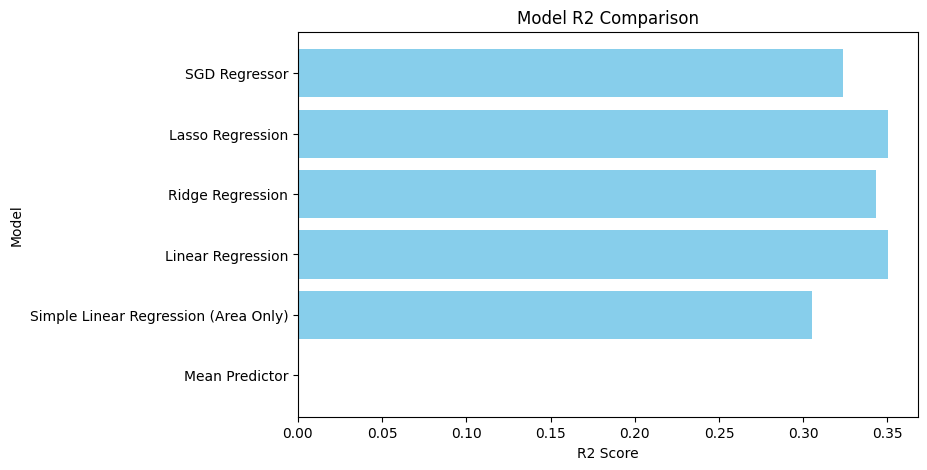

In [702]:
# Model comparison result visual bar
plt.figure(figsize=(8, 5))
plt.barh(final_results["Model"], final_results["R2"], color="skyblue")
plt.xlabel("R2 Score")
plt.ylabel("Model")
plt.title("Model R2 Comparison")
plt.show()

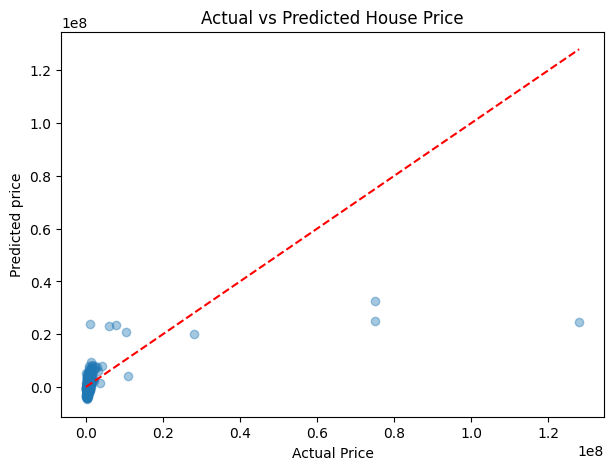

In [703]:
# Model performance Actual vs Predicted
plt.figure(figsize=[7, 5])
plt.scatter(y_test, y_pred_lr, alpha=0.4)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted House Price")
plt.show()

All multivariate regression models outperform the baseline predictors, confirming that numerical housing features provide meaningful predictive power. Regularized models such as Ridge and Lasso demonstrate improved generalizaion performance, while SGDRegressor offers competitive results with efficient optimization.

In [704]:
# for testing
a_house = pd.DataFrame([{
    "beds": 4,
    "baths": 2,
    "area_sqft": 2000,
    "home_type": "Single_family",
    "state_code": "TX"
}])

predicted_price = lin_reg.predict(a_house)
print("$",round(predicted_price[0], 2))


$ 378012.38


c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
